In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

In [2]:
#_____TASK 1_____

In [3]:
np.random.seed(42)

data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

w = np.random.randn(30) * 0.01
b = np.random.randn() * 0.01

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(x, w, b):
    z = np.dot(x, w) + b
    return sigmoid(z)

print("Predicted probabilities:\n")

for i in range(5):
    prob = forward(X_test[i], w, b)
    print(f"Sample {i+1}: {prob:.6f}")

Predicted probabilities:

Sample 1: 0.496225
Sample 2: 0.517540
Sample 3: 0.507080
Sample 4: 0.487440
Sample 5: 0.483946


*The model implemented is a single-layer logistic regression classifier (a single artificial neuron with sigmoid activation)*

In [4]:
#_____TASK 2_____

In [5]:
class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1):
        np.random.seed(42)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def relu(self, z):
        return np.maximum(0, z)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = self.relu(Z1)

        Z2 = np.dot(A1, self.W2) + self.b2
        A2 = self.sigmoid(Z2)

        return A2

mlp = NumpyMLP()

predictions = mlp.forward(X_test)

print("Output shape:", predictions.shape)

print("\nFirst 5 predictions:")
print(predictions[:5])

Output shape: (114, 1)

First 5 predictions:
[[0.45299955]
 [0.46601069]
 [0.56604814]
 [0.40817775]
 [0.36364703]]


In [6]:
#_____TASK 3_____

In [7]:
class TorchMLP(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)
        self.activation = activation
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.activation(z1)
        z2 = self.fc2(a1)
        out = self.output_activation(z2)
        return out, z1, a1

numpy_mlp = NumpyMLP()
numpy_preds = numpy_mlp.forward(X_test)

torch_mlp = TorchMLP(nn.ReLU())

torch_mlp.fc1.weight.data = torch.from_numpy(numpy_mlp.W1.T).float()
torch_mlp.fc1.bias.data = torch.from_numpy(numpy_mlp.b1).float().view(-1)

torch_mlp.fc2.weight.data = torch.from_numpy(numpy_mlp.W2.T).float()
torch_mlp.fc2.bias.data = torch.from_numpy(numpy_mlp.b2).float().view(-1)

X_test_tensor = torch.from_numpy(X_test).float()

with torch.no_grad():
    torch_preds, _, _ = torch_mlp(X_test_tensor)
    torch_preds = torch_preds.numpy()

max_diff = np.max(np.abs(numpy_preds - torch_preds))

print("NumPy predictions (first 5):")
print(numpy_preds[:5])

print("\nPyTorch predictions (first 5):")
print(torch_preds[:5])

print("\nMaximum absolute difference:")
print(max_diff)

NumPy predictions (first 5):
[[0.45299955]
 [0.46601069]
 [0.56604814]
 [0.40817775]
 [0.36364703]]

PyTorch predictions (first 5):
[[0.45299956]
 [0.4660107 ]
 [0.56604815]
 [0.40817776]
 [0.363647  ]]

Maximum absolute difference:
6.359250637189007e-08


In [8]:
#_____TASK 4_____

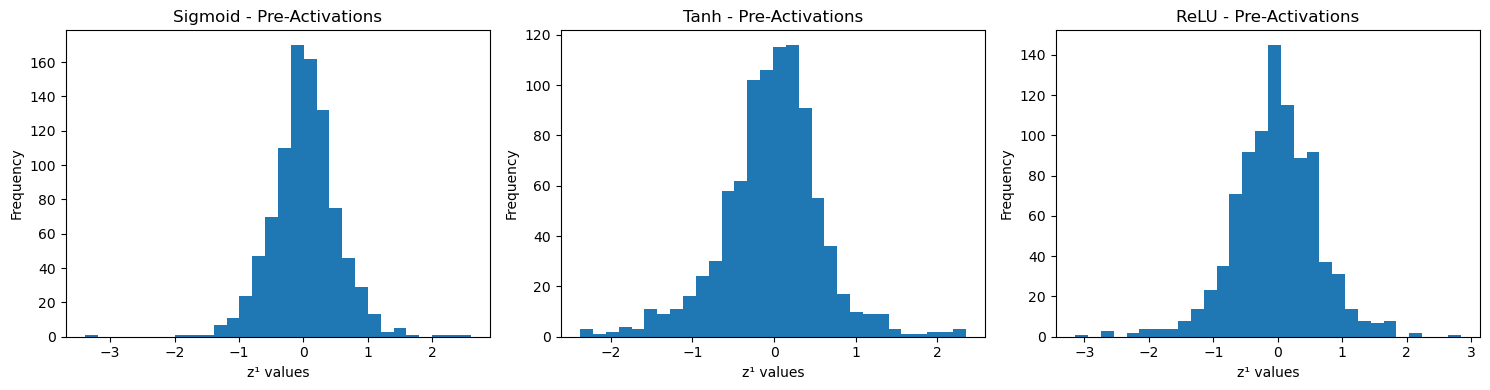

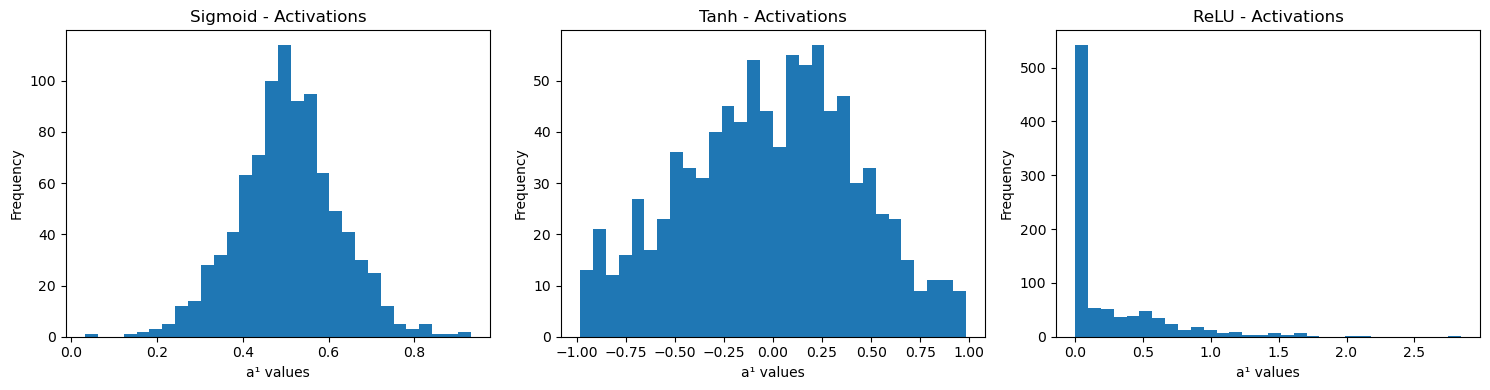

In [9]:
models = {
    "Sigmoid": TorchMLP(nn.Sigmoid()),
    "Tanh": TorchMLP(nn.Tanh()),
    "ReLU": TorchMLP(nn.ReLU())
}

X_test_tensor = torch.from_numpy(X_test).float()

pre_activations = {}
post_activations = {}

with torch.no_grad():
    for name, model in models.items():
        output, z1, a1 = model(X_test_tensor)

        pre_activations[name] = z1.numpy().flatten()
        post_activations[name] = a1.numpy().flatten()


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, values) in zip(axes, pre_activations.items()):
    ax.hist(values, bins=30)
    ax.set_title(f"{name} - Pre-Activations")
    ax.set_xlabel("z¹ values")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, values) in zip(axes, post_activations.items()):
    ax.hist(values, bins=30)
    ax.set_title(f"{name} - Activations")
    ax.set_xlabel("a¹ values")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Sigmoid saturated region:** The vast majority of values fall between 0.3–0.8 (the active middle zone), so only roughly **~5–10%** are near 0 or 1 and saturated.

**Tanh saturated region:** Values spread across the full ±1 range with noticeable tails, so approximately **~15–20%** of post-activation values fall in the saturated regions close to ±1.

**ReLU inactive units:** The massive spike at 0 (frequency 500) compared to all other bins indicates roughly **~50% of units are dead**, outputting exactly 0 due to negative pre-activations being clamped.

**Why ReLU is the better default:** Unlike Sigmoid and Tanh, ReLU's gradient is a constant 1 for all positive inputs, completely avoiding the vanishing gradient problem that slows learning in deeper networks. The sparsity from zero outputs also reduces neuron co-dependence, and `max(0,z)` is computationally trivial compared to exponential functions.